# Experimento  MS COCO multilabel: CRC vs AA-CRC vs ReCIRC-TabICL

Implementação unificada do **Experimento 2** do documento ReCIRC (Seção 6.3 do PDF), reproduzindo o
experimento canônico do paper original do CRC (escores **TResNet-XL** da pasta `coco` do repositório oficial).

**Métodos comparados**

| Método | Reparametrização | Features |
|---|---|---|
| **CRC marginal** | global \(\lambda\) | — |
| **AA-CRC** (Blot et al., 2025) | \(\hat\lambda(x)=\phi(x)^\top\theta\) (linear) | resumo + 80 escores (igual ao ReCIRC) |
| **ReCIRC-TabICL** | inversão de \(\hat R(\lambda\mid x)\) (Rota 2) | resumo + 80 escores |

**Decisões de projeto (correções em relação às versões anteriores)**

1. **Sem embeddings de imagem** — todos usam representações derivadas das probabilidades \(\hat p(x)\),
   como prescreve a Seção 6 do PDF ("use the base model's estimated probabilities ... enriched with entropy,
   margins, set size"). Isso mantém o experimento na forma canônica do CRC e torna AA-CRC vs ReCIRC uma
   ablação limpa sobre a *reparametrização*, não sobre a representação.
2. **Difficulty score label-free** (entropia dos escores) para os bins de cobertura condicional — a Seção 6.1
   exige um score que *não use o rótulo de teste*.
3. **Orçamento de dados justo** (`FAIR_BUDGET`): CRC e AA-CRC calibram sobre \(D\cup\text{cal}\); ReCIRC ajusta
   \(\hat R\) em \(D\) e calibra o escalar \(a\) em cal. Todos veem o mesmo total de imagens rotuladas.
4. **Loss**: \(\ell_\lambda(x,y)=1-\mathrm{recall}(\hat C_\lambda(x),y)\), \(\hat C_\lambda=\{k:\hat p_k(x)\ge\lambda\}\), \(B=1\), \(\alpha=0.10\).


## 1. Instalação, clone do AA-CRC e imports

In [1]:
# ============================================================
# Instalações (Colab). Rode uma vez por sessão.
# ============================================================
import os, sys, subprocess

def sh(cmd):
    print("$", cmd)
    return os.system(cmd)

# TabICL (estimador de risco in-context)
try:
    from tabicl import TabICLRegressor
    print("TabICL já instalado.")
except ImportError:
    sh(f"{sys.executable} -m pip install -q tabicl")

# gdown para baixar os escores pré-computados
try:
    import gdown  # noqa
except ImportError:
    sh(f"{sys.executable} -m pip install -q gdown")

# Repositório oficial do AA-CRC (Blot et al., AISTATS 2025)
if not os.path.exists("AA-CRC"):
    sh("git clone -q https://github.com/vincentblot28/AA-CRC.git")


$ /usr/bin/python3 -m pip install -q tabicl
$ git clone -q https://github.com/vincentblot28/AA-CRC.git


In [2]:
# ============================================================
# Imports
# ============================================================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler

# TabICL
try:
    from tabicl import TabICLRegressor
    HAS_TABICL = True
except Exception as e:
    HAS_TABICL = False
    print(f"TabICL indisponível ({e}). ReCIRC-TabICL será pulado.")

# Device
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

# AA-CRC (clonado acima). Se a importação falhar, o pipeline roda sem esse baseline.
sys.path.insert(0, "AA-CRC")
try:
    from multiaccurate_cp.utils.multiaccurate import J, J_prime
    from scipy.optimize import minimize
    HAS_AACRC = True
    print("AA-CRC importado.")
except Exception as e:
    HAS_AACRC = False
    print(f"AA-CRC indisponível ({e}). Esse baseline será pulado.")

plt.rcParams.update({"figure.dpi": 110})


Device: cuda
AA-CRC importado.


## 2. Configuração

In [3]:
# ============================================================
# Hiperparâmetros do experimento
# ============================================================
ALPHA   = 0.10
B       = 1.0

N_D     = 1000       # contexto: treina hat R(lambda | x) para o ReCIRC
N_CAL   = 1500      # calibração do escalar 'a' (ReCIRC) / threshold (CRC, AA-CRC)
N_BINS  = 5         # bins de dificuldade (cobertura condicional)
DIFFICULTY_KIND = "entropy"   # label-free

LAMBDA_GRID = np.linspace(0.0, 1.0, 26)     # grade de thresholds
A_GRID      = np.linspace(0.0, 0.5, 101)    # grade de risk-budgets 'a' (fina perto de alpha)

INCLUDE_FULL_SCORES = True    # ReCIRC usa resumo + 80 escores
N_D_TABICL  = 1000             # subamostra de D para o contexto do TabICL
LAMBDA_RIDGE = 0.01           # regularização do AA-CRC (valor do paper)

FAIR_BUDGET = True            # CRC/AA-CRC calibram em D∪cal (mesmo total rotulado que o ReCIRC)

# Flags de método (desligue para acelerar)
USE_AACRC   = HAS_AACRC
USE_TABICL  = HAS_TABICL

N_TRIALS    = 5               # múltiplos splits para variância. AA-CRC+TabICL custam; aumente se viável.
BASE_SEED   = 42


## 3. Carregamento dos escores TResNet-XL

`coco-tresnetxl.npz` contém `sgmd` (probabilidades sigmoide, shape \((N,80)\)) e `labels` (binário, \((N,80)\)).


In [4]:
# ============================================================
# Download e load
# ============================================================
DATA_DIR = "./data"
NPZ_PATH = f"{DATA_DIR}/coco/coco-tresnetxl.npz"
GDRIVE_ID = "1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK"   # id do .tar.gz com os escores

if not os.path.exists(NPZ_PATH):
    print("Baixando escores pré-computados...")
    sh(f"gdown {GDRIVE_ID} -O ./data.tar.gz")
    sh("tar -xf ./data.tar.gz")
    sh("rm -f ./data.tar.gz")
else:
    print(f"{NPZ_PATH} já existe.")

data = np.load(NPZ_PATH)
sgmd   = data["sgmd"].astype(np.float32)
labels = data["labels"].astype(np.int8)

# FNR é indefinido quando sum(y)=0 -> manter só imagens com >=1 positivo
keep = labels.sum(1) > 0
sgmd, labels = sgmd[keep], labels[keep]
N_CLASSES = sgmd.shape[1]
print(f"sgmd: {sgmd.shape} | labels: {labels.shape} | classes: {N_CLASSES}")


Baixando escores pré-computados...
$ gdown 1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK -O ./data.tar.gz
$ tar -xf ./data.tar.gz
$ rm -f ./data.tar.gz
sgmd: (4952, 80) | labels: (4952, 80) | classes: 80


## 4. Funções básicas — perdas, features, bins de dificuldade

In [5]:
# ============================================================
# Perdas e conjuntos
# ============================================================
def prediction_sets(scores, lam):
    if np.isscalar(lam):
        return scores >= lam
    return scores >= lam[:, None]

def per_image_fnr(pred_set, gt_labels):
    denom = gt_labels.sum(axis=1).clip(min=1)
    recall_i = (pred_set * gt_labels).sum(axis=1) / denom
    return 1.0 - recall_i

def avg_fnr(pred_set, gt_labels):
    return float(per_image_fnr(pred_set, gt_labels).mean())

def evaluate_pred_set(pred_set, gt_labels):
    return {"fnr": avg_fnr(pred_set, gt_labels),
            "avg_size": float(pred_set.sum(axis=1).mean())}


In [6]:
# ============================================================
# Features derivadas das probabilidades
# ============================================================
SUMMARY_COLS = ["max_score","second_score","third_score","sum_scores","mean_score",
                "sd_score","entropy","n_above_005","n_above_010","n_above_020","n_above_050"]

def summary_features(scores):
    eps = 1e-12
    s_sorted = np.sort(scores, axis=1)[:, ::-1]
    entropy = -np.sum(scores*np.log(scores+eps) + (1-scores)*np.log(1-scores+eps), axis=1)
    return pd.DataFrame({
        "max_score":    s_sorted[:, 0],
        "second_score": s_sorted[:, 1],
        "third_score":  s_sorted[:, 2],
        "sum_scores":   scores.sum(axis=1),
        "mean_score":   scores.mean(axis=1),
        "sd_score":     scores.std(axis=1),
        "entropy":      entropy,
        "n_above_005":  (scores >= 0.05).sum(axis=1),
        "n_above_010":  (scores >= 0.10).sum(axis=1),
        "n_above_020":  (scores >= 0.20).sum(axis=1),
        "n_above_050":  (scores >= 0.50).sum(axis=1),
    })

def make_features(scores, include_full_scores=True):
    X = summary_features(scores)
    if include_full_scores:
        cols = pd.DataFrame(scores, columns=[f"score_{j:02d}" for j in range(scores.shape[1])])
        X = pd.concat([X.reset_index(drop=True), cols.reset_index(drop=True)], axis=1)
    return X


In [7]:
# ============================================================
# Difficulty score (label-free) e bins
# ============================================================
def difficulty_score(scores, kind="entropy"):
    X = summary_features(scores)
    if kind == "entropy":
        return X["entropy"].to_numpy()
    if kind == "neg_max_score":
        return -X["max_score"].to_numpy()
    raise ValueError(kind)

def fit_difficulty_edges(scores, n_bins=5, kind="entropy"):
    diff = difficulty_score(scores, kind=kind)
    edges = np.unique(np.quantile(diff, np.linspace(0, 1, n_bins + 1))).astype(float)
    if len(edges) < n_bins + 1:
        edges = np.linspace(diff.min(), diff.max(), n_bins + 1)
    edges[0], edges[-1] = -np.inf, np.inf
    return edges

def apply_difficulty_bins(scores, edges, kind="entropy"):
    diff = difficulty_score(scores, kind=kind)
    return pd.cut(diff, bins=edges, labels=False, include_lowest=True).astype(int)


## 5. CRC marginal (baseline)

In [8]:
# ============================================================
# CRC marginal: maior lambda com (n/(n+1)) R(lambda) + B/(n+1) <= alpha
# (FNR cresce em lambda -> o conjunto valido e um prefixo; pega-se o ultimo)
# ============================================================
def risk_curve(scores, gt_labels, lambda_grid):
    return np.array([avg_fnr(prediction_sets(scores, lam), gt_labels) for lam in lambda_grid])

def choose_lambda_crc(scores, gt_labels, alpha, lambda_grid, B=1.0):
    n = scores.shape[0]
    risks = risk_curve(scores, gt_labels, lambda_grid)
    bound = (n/(n+1))*risks + B/(n+1)
    valid = np.where(bound <= alpha)[0]
    return float(lambda_grid[valid[-1]]) if len(valid) else float(lambda_grid[0])


## 6. AA-CRC (Blot et al., 2025)

Threshold linear input-dependente \(\hat\lambda(x)=\phi(x)^\top\theta\), com \(\theta\) por SLSQP minimizando o
objetivo \(J\) do código oficial. \(\phi(x)\) = **as mesmas features do ReCIRC** (resumo + 80 escores)
padronizadas + intercepto — comparação justa; o ridge absorve a colinearidade entre escores e resumos.
O otimizador parte de um **init estável** (coeficientes nulos, intercepto \(=0{,}5\)) para garantir
\(\phi^\top\theta>0\) em todas as linhas no início — caso contrário o gate `max(0,·)` zera o gradiente de
muitos exemplos e o SLSQP subaproveita as features.


In [9]:
# ============================================================
# AA-CRC
# ============================================================
def run_aacrc(cal_scores, cal_labels, test_scores, alpha, lambda_ridge=0.01,
              include_full_scores=True, seed=0):
    if not HAS_AACRC:
        return None
    n = cal_scores.shape[0]

    # Mesmas features do ReCIRC (resumo + 80 escores) -> comparacao justa.
    # Ridge (lambda_ridge) absorve a colinearidade entre escores e resumos.
    feat = lambda s: make_features(s, include_full_scores=include_full_scores).values
    scaler = StandardScaler().fit(feat(cal_scores))
    Phi_cal  = scaler.transform(feat(cal_scores))
    Phi_test = scaler.transform(feat(test_scores))
    Phi_cal_b  = np.concatenate([np.ones((len(Phi_cal),1)),  Phi_cal ], axis=1).astype(np.float64)
    Phi_test_b = np.concatenate([np.ones((len(Phi_test),1)), Phi_test], axis=1).astype(np.float64)
    D = Phi_cal_b.shape[1]

    # eixo fantasma exigido por J/J_prime (originalmente p/ segmentacao): (n, K, 1)
    Y_aa = cal_labels[:, :, None].astype(np.float64)
    P_aa = cal_scores[:, :, None].astype(np.float64)

    # Init estavel: coeficientes nulos + intercepto positivo => phi^T theta = 0.5 > 0 em
    # TODAS as linhas (parte de um limiar constante; o otimizador introduz a adaptatividade).
    # Evita que o gate max(0,.) zere o gradiente de exemplos e o SLSQP subaproveite os escores.
    theta0 = np.zeros(D)
    theta0[0] = 0.5   # coluna 0 = intercepto

    t0 = time.time()
    res = minimize(J, x0=theta0, method="SLSQP",
                   args=(Y_aa, P_aa, Phi_cal_b, alpha, n, "ridge", lambda_ridge),
                   jac=J_prime, options={"maxiter": 1000, "disp": False}, tol=1e-10)
    dt = time.time() - t0

    lam_test = np.clip(Phi_test_b @ res.x, 0.0, 1.0)
    pred = prediction_sets(test_scores, lam_test)
    return {"pred": pred, "lambdas": lam_test, "theta": res.x, "time": dt}


## 7. ReCIRC — Rota 2 (regressão direta de \(\hat R(\lambda\mid x)\))

O estimador de risco é o **TabICL**: (1) dataset aumentado \((\phi(X_i),\lambda_m)\mapsto Z=\ell_{\lambda_m}\);
(2) ajusta \(\hat R\) em \(D\); (3) inverte \(\hat\lambda_a(x)=\sup\{\lambda:\hat R(\lambda\mid x)\le a\}\); (4) calibra \(a\) por CRC em cal.


In [10]:
# ============================================================
# Dataset aumentado + ajuste do regressor de risco
# ============================================================
def build_augmented(scores, gt_labels, lambda_grid, include_full_scores=True):
    base = make_features(scores, include_full_scores=include_full_scores)
    feat_cols = list(base.columns)
    base_arr = base.values
    n, M = scores.shape[0], len(lambda_grid)
    Z = np.empty((n, M), dtype=np.float32)
    for m, lam in enumerate(lambda_grid):
        Z[:, m] = per_image_fnr(prediction_sets(scores, lam), gt_labels)
    X_aug = np.concatenate([np.repeat(base_arr, M, axis=0),
                            np.tile(lambda_grid, n).reshape(-1, 1)], axis=1)
    return X_aug.astype(np.float32), Z.reshape(-1), feat_cols

def fit_risk_model(X_aug, Z, kind="tabicl", device="cpu", seed=0):
    if kind == "tabicl":
        model = TabICLRegressor(n_estimators=4, device=device, random_state=seed)
        model.fit(X_aug, Z)
    else:
        raise ValueError(kind)
    return model

def predict_risk_matrix(model, scores, lambda_grid, include_full_scores=True, enforce_monotone=True):
    base = make_features(scores, include_full_scores=include_full_scores).values
    n, M = scores.shape[0], len(lambda_grid)
    X = np.concatenate([np.repeat(base, M, axis=0),
                        np.tile(lambda_grid, n).reshape(-1, 1)], axis=1).astype(np.float32)
    R = np.clip(model.predict(X), 0, 1).reshape(n, M)
    if enforce_monotone:               # FNR cresce em lambda
        R = np.maximum.accumulate(R, axis=1)
    return R


In [11]:
# ============================================================
# Inversao, calibracao de 'a' e predicao
# ============================================================
def invert_risk_curve(R, lambda_grid, a):
    # R crescente em lambda -> {lambda: R<=a} e um prefixo; pega o ultimo indice
    valid = R <= a
    n_valid = valid.sum(axis=1)
    last_idx = np.maximum(n_valid - 1, 0)
    lambdas = lambda_grid[last_idx]
    fallback = R[:, 0] > a          # nem o menor lambda satisfaz -> mais protetor
    return np.where(fallback, lambda_grid[0], lambdas)

def recirc_calibration_risk(scores_cal, gt_cal, R_cal, lambda_grid, a_grid):
    risks = np.empty(len(a_grid))
    for k, a in enumerate(a_grid):
        lambdas = invert_risk_curve(R_cal, lambda_grid, a)
        risks[k] = per_image_fnr(prediction_sets(scores_cal, lambdas), gt_cal).mean()
    return risks

def recirc_choose_a(risks_cal, a_grid, n_cal, alpha, B=1.0):
    bound = (n_cal/(n_cal+1))*risks_cal + B/(n_cal+1)
    valid = np.where(bound <= alpha)[0]
    return float(a_grid[valid[-1]]) if len(valid) else float(a_grid[0])

def run_recirc(kind, D_scores, D_labels, cal_scores, cal_labels, test_scores,
               lambda_grid, a_grid, alpha, include_full_scores=True,
               n_d_tabicl=500, device="cpu", seed=0):
    rng = np.random.default_rng(seed)
    # contexto D (subamostrado para o TabICL)
    if kind == "tabicl" and len(D_scores) > n_d_tabicl:
        idx = rng.choice(len(D_scores), n_d_tabicl, replace=False)
        D_sc, D_lb = D_scores[idx], D_labels[idx]
    else:
        D_sc, D_lb = D_scores, D_labels

    t0 = time.time()
    X_aug, Z, _ = build_augmented(D_sc, D_lb, lambda_grid, include_full_scores)
    model = fit_risk_model(X_aug, Z, kind, device=device, seed=seed)
    t_fit = time.time() - t0

    t0 = time.time()
    R_cal  = predict_risk_matrix(model, cal_scores,  lambda_grid, include_full_scores)
    R_test = predict_risk_matrix(model, test_scores, lambda_grid, include_full_scores)
    risks_cal = recirc_calibration_risk(cal_scores, cal_labels, R_cal, lambda_grid, a_grid)
    a_hat = recirc_choose_a(risks_cal, a_grid, n_cal=len(cal_scores), alpha=alpha)
    lambdas_test = invert_risk_curve(R_test, lambda_grid, a_hat)
    pred = prediction_sets(test_scores, lambdas_test)
    t_inf = time.time() - t0
    return {"pred": pred, "lambdas": lambdas_test, "a_hat": a_hat,
            "risks_cal": risks_cal, "time": t_fit + t_inf}


## 8. Split único — execução detalhada e sanity check

In [12]:
# ============================================================
# Split principal: D / cal / test
# ============================================================
rng = np.random.default_rng(BASE_SEED)
perm = rng.permutation(len(sgmd))
D_idx   = perm[:N_D]
cal_idx = perm[N_D:N_D + N_CAL]
test_idx= perm[N_D + N_CAL:]

D_scores,   D_labels   = sgmd[D_idx],   labels[D_idx]
cal_scores, cal_labels = sgmd[cal_idx], labels[cal_idx]
test_scores,test_labels= sgmd[test_idx],labels[test_idx]

# Orcamento justo: CRC/AA-CRC calibram em D∪cal
if FAIR_BUDGET:
    calM_scores = np.concatenate([D_scores, cal_scores], axis=0)
    calM_labels = np.concatenate([D_labels, cal_labels], axis=0)
else:
    calM_scores, calM_labels = cal_scores, cal_labels

bin_edges = fit_difficulty_edges(D_scores, n_bins=N_BINS, kind=DIFFICULTY_KIND)
test_bins = apply_difficulty_bins(test_scores, bin_edges, kind=DIFFICULTY_KIND)

print(f"N={len(sgmd)} | D={len(D_idx)} | cal={len(cal_idx)} | test={len(test_idx)} "
      f"| calM(CRC/AA-CRC)={len(calM_scores)}")


N=4952 | D=1000 | cal=1500 | test=2452 | calM(CRC/AA-CRC)=2500


In [13]:
# ============================================================
# Roda todos os metodos habilitados (split unico)
# ============================================================
results = {}

# CRC marginal
lam_crc = choose_lambda_crc(calM_scores, calM_labels, ALPHA, LAMBDA_GRID, B=B)
pred_crc = prediction_sets(test_scores, lam_crc)
results["CRC marginal"] = {"pred": pred_crc,
                           "lambdas": np.full(len(test_scores), lam_crc),
                           **evaluate_pred_set(pred_crc, test_labels)}
print(f"CRC marginal: lambda={lam_crc:.4f} | FNR={results['CRC marginal']['fnr']:.4f} "
      f"| tam={results['CRC marginal']['avg_size']:.2f}")

# AA-CRC
if USE_AACRC:
    out = run_aacrc(calM_scores, calM_labels, test_scores, ALPHA, LAMBDA_RIDGE,
                    include_full_scores=INCLUDE_FULL_SCORES, seed=0)
    if out is not None:
        results["AA-CRC"] = {**out, **evaluate_pred_set(out["pred"], test_labels)}
        print(f"AA-CRC: FNR={results['AA-CRC']['fnr']:.4f} | tam={results['AA-CRC']['avg_size']:.2f} "
              f"| lambda(mean±sd)={out['lambdas'].mean():.3f}±{out['lambdas'].std():.3f} "
              f"| {out['time']:.1f}s")

# ReCIRC-TabICL
if USE_TABICL:
    out = run_recirc("tabicl", D_scores, D_labels, cal_scores, cal_labels, test_scores,
                     LAMBDA_GRID, A_GRID, ALPHA, INCLUDE_FULL_SCORES,
                     n_d_tabicl=N_D_TABICL, device=DEVICE, seed=0)
    results["ReCIRC-TabICL"] = {**out, **evaluate_pred_set(out["pred"], test_labels)}
    print(f"ReCIRC-TabICL: a_hat={out['a_hat']:.4f} | FNR={results['ReCIRC-TabICL']['fnr']:.4f} "
          f"| tam={results['ReCIRC-TabICL']['avg_size']:.2f} | {out['time']:.1f}s")


CRC marginal: lambda=0.7200 | FNR=0.0910 | tam=3.05
AA-CRC: FNR=0.0886 | tam=3.98 | lambda(mean±sd)=0.759±0.162 | 65.2s


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

ReCIRC-TabICL: a_hat=0.1600 | FNR=0.0967 | tam=3.35 | 27.4s


In [14]:
# ============================================================
# Tabela do split unico + sanity check de orientacao
# ============================================================
df_single = pd.DataFrame([
    {"método": name, "FNR": r["fnr"], "tam_médio": r["avg_size"],
     "lambda_médio": float(np.mean(r["lambdas"])), "lambda_sd": float(np.std(r["lambdas"]))}
    for name, r in results.items()
])
print(df_single.round(4).to_string(index=False))

se = np.sqrt(ALPHA*(1-ALPHA)/len(test_labels))
print(f"\nSanity check — FNR deve cair perto de alpha={ALPHA} (±2SE = ±{2*se:.4f}). "
      f"Se algum sair ~{1-ALPHA}, a orientacao de lambda esta invertida.")
for name, r in results.items():
    print(f"  {name:16s} z=({r['fnr']:.4f}-{ALPHA})/SE = {(r['fnr']-ALPHA)/se:+.2f}")


       método    FNR  tam_médio  lambda_médio  lambda_sd
 CRC marginal 0.0910     3.0489        0.7200     0.0000
       AA-CRC 0.0886     3.9759        0.7594     0.1620
ReCIRC-TabICL 0.0967     3.3458        0.8312     0.1547

Sanity check — FNR deve cair perto de alpha=0.1 (±2SE = ±0.0121). Se algum sair ~0.9, a orientacao de lambda esta invertida.
  CRC marginal     z=(0.0910-0.1)/SE = -1.49
  AA-CRC           z=(0.0886-0.1)/SE = -1.89
  ReCIRC-TabICL    z=(0.0967-0.1)/SE = -0.54


In [15]:
# ============================================================
# Curva de calibracao do ReCIRC (TabICL)
# ============================================================

# cal_src = "ReCIRC-TabICL" if "ReCIRC-TabICL" in results else None
# if cal_src:
#     risks_cal = results[cal_src]["risks_cal"]
#     a_hat = results[cal_src]["a_hat"]
#     n_c = len(cal_scores)
#     bound = (n_c/(n_c+1))*risks_cal + B/(n_c+1)
#     fig, ax = plt.subplots(figsize=(7, 4))
#     ax.plot(A_GRID, risks_cal, marker="o", ms=3, label=r"$\widehat R^R_{cal}(a)$")
#     ax.plot(A_GRID, bound, marker="s", ms=3, label=r"$\frac{n}{n+1}\widehat R+\frac{B}{n+1}$")
#     ax.axhline(ALPHA, ls="--", color="gray", label=fr"$\alpha={ALPHA}$")
#    ax.axvline(a_hat, ls=":", color="red", label=fr"$\hat a={a_hat:.3f}$")
#    ax.plot([0, .5], [0, .5], ls=":", color="black", lw=.6, label="y=x")
#    ax.set_xlabel("a (risk budget)"); ax.set_ylabel("Risco")
#    ax.set_title(f"Calibração ReCIRC — {cal_src}"); ax.legend(fontsize=9); ax.grid(alpha=.3)
#    plt.tight_layout(); plt.show()


## 9. Múltiplos splits — variância

In [16]:
# ============================================================
# Pipeline de um split (todos os metodos)
# ============================================================
def conditional_by_bin(pred, gt_labels, bins, n_bins, name):
    loss_i = per_image_fnr(pred, gt_labels)
    size_i = pred.sum(axis=1)
    rows = []
    for b in range(n_bins):
        mask = bins == b
        rows.append({"method": name, "bin": b, "n": int(mask.sum()),
                     "conditional_risk": float(loss_i[mask].mean()) if mask.any() else np.nan,
                     "mean_set_size":   float(size_i[mask].mean()) if mask.any() else np.nan})
    return pd.DataFrame(rows)

def run_one_split(scores, gt_labels, seed):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(scores))
    D_i, c_i, t_i = perm[:N_D], perm[N_D:N_D+N_CAL], perm[N_D+N_CAL:]
    D_sc, D_lb = scores[D_i], gt_labels[D_i]
    c_sc, c_lb = scores[c_i], gt_labels[c_i]
    t_sc, t_lb = scores[t_i], gt_labels[t_i]
    if FAIR_BUDGET:
        cM_sc = np.concatenate([D_sc, c_sc]); cM_lb = np.concatenate([D_lb, c_lb])
    else:
        cM_sc, cM_lb = c_sc, c_lb

    edges = fit_difficulty_edges(D_sc, n_bins=N_BINS, kind=DIFFICULTY_KIND)
    t_bins = apply_difficulty_bins(t_sc, edges, kind=DIFFICULTY_KIND)

    preds = {}
    lam_per_image = {}
    # CRC
    lam = choose_lambda_crc(cM_sc, cM_lb, ALPHA, LAMBDA_GRID, B=B)
    preds["CRC marginal"] = prediction_sets(t_sc, lam); lam_per_image["CRC marginal"] = None
    # AA-CRC
    if USE_AACRC:
        o = run_aacrc(cM_sc, cM_lb, t_sc, ALPHA, LAMBDA_RIDGE,
                      include_full_scores=INCLUDE_FULL_SCORES, seed=seed)
        if o is not None:
            preds["AA-CRC"] = o["pred"]; lam_per_image["AA-CRC"] = o["lambdas"]
    # ReCIRC-TabICL
    if USE_TABICL:
        o = run_recirc("tabicl", D_sc, D_lb, c_sc, c_lb, t_sc, LAMBDA_GRID, A_GRID, ALPHA,
                       INCLUDE_FULL_SCORES, n_d_tabicl=N_D_TABICL, device=DEVICE, seed=seed)
        preds["ReCIRC-TabICL"] = o["pred"]; lam_per_image["ReCIRC-TabICL"] = o["lambdas"]

    marg, cond, adapt = [], [], []
    for name, pset in preds.items():
        ev = evaluate_pred_set(pset, t_lb)
        marg.append({"method": name, "test_fnr": ev["fnr"], "avg_size": ev["avg_size"]})
        cond.append(conditional_by_bin(pset, t_lb, t_bins, N_BINS, name))
        lp = lam_per_image[name]
        if lp is not None:
            for b in range(N_BINS):
                m = t_bins == b
                if m.any():
                    adapt.append({"method": name, "bin": b,
                                  "mean_lambda": float(lp[m].mean()), "sd_lambda": float(lp[m].std())})
    return pd.DataFrame(marg), pd.concat(cond, ignore_index=True), pd.DataFrame(adapt)


In [17]:
# ============================================================
# Roda N_TRIALS splits
# ============================================================
marg_list, cond_list, adapt_list = [], [], []
for t in tqdm(range(N_TRIALS), desc="Trials"):
    m, c, a = run_one_split(sgmd, labels, seed=BASE_SEED + t)
    for d in (m, c, a):
        d["trial"] = t
    marg_list.append(m); cond_list.append(c); adapt_list.append(a)

df_marginal    = pd.concat(marg_list, ignore_index=True)
df_conditional = pd.concat(cond_list, ignore_index=True)
df_adapt       = pd.concat(adapt_list, ignore_index=True) if any(len(a) for a in adapt_list) else pd.DataFrame()
print(f"Concluído: {N_TRIALS} trials.")


Trials:   0%|          | 0/5 [00:00<?, ?it/s]

Concluído: 5 trials.


## 10. Resumos agregados

In [18]:
# ============================================================
# Resumo marginal + condicional
# ============================================================
summary_marginal = (df_marginal.groupby("method", as_index=False)
    .agg(mean_test_fnr=("test_fnr","mean"), sd_test_fnr=("test_fnr","std"),
         mean_avg_size=("avg_size","mean"), sd_avg_size=("avg_size","std"),
         violation_rate=("test_fnr", lambda x: float(np.mean(x > ALPHA)))))

cond = df_conditional.copy()
cond["excess"] = np.maximum(cond["conditional_risk"] - ALPHA, 0.0)
per_trial = (cond.groupby(["trial","method"], as_index=False)
    .agg(worst_bin_risk=("conditional_risk","max"), mean_excess_by_bin=("excess","mean")))
summary_conditional = (per_trial.groupby("method", as_index=False)
    .agg(mean_worst_bin=("worst_bin_risk","mean"), sd_worst_bin=("worst_bin_risk","std"),
         mean_excess=("mean_excess_by_bin","mean")))

summary = summary_marginal.merge(summary_conditional, on="method", how="left")
# ordenacao consistente
order = ["CRC marginal","AA-CRC","ReCIRC-TabICL"]
summary["__o"] = summary["method"].apply(lambda m: order.index(m) if m in order else 99)
summary = summary.sort_values("__o").drop(columns="__o").reset_index(drop=True)
summary.round(4)


,method,mean_test_fnr,sd_test_fnr,mean_avg_size,sd_avg_size,violation_rate,mean_worst_bin,sd_worst_bin,mean_excess
0,CRC marginal,0.0936,0.0076,3.0100,0.0964,0.2,0.1795,0.0185,0.0193
1,AA-CRC,0.0885,0.0055,3.7647,0.1670,0.0,0.1006,0.0068,0.0009
2,ReCIRC-TabICL,0.0974,0.0038,3.2119,0.0916,0.2,0.1386,0.0049,0.0146


## 11. Figuras

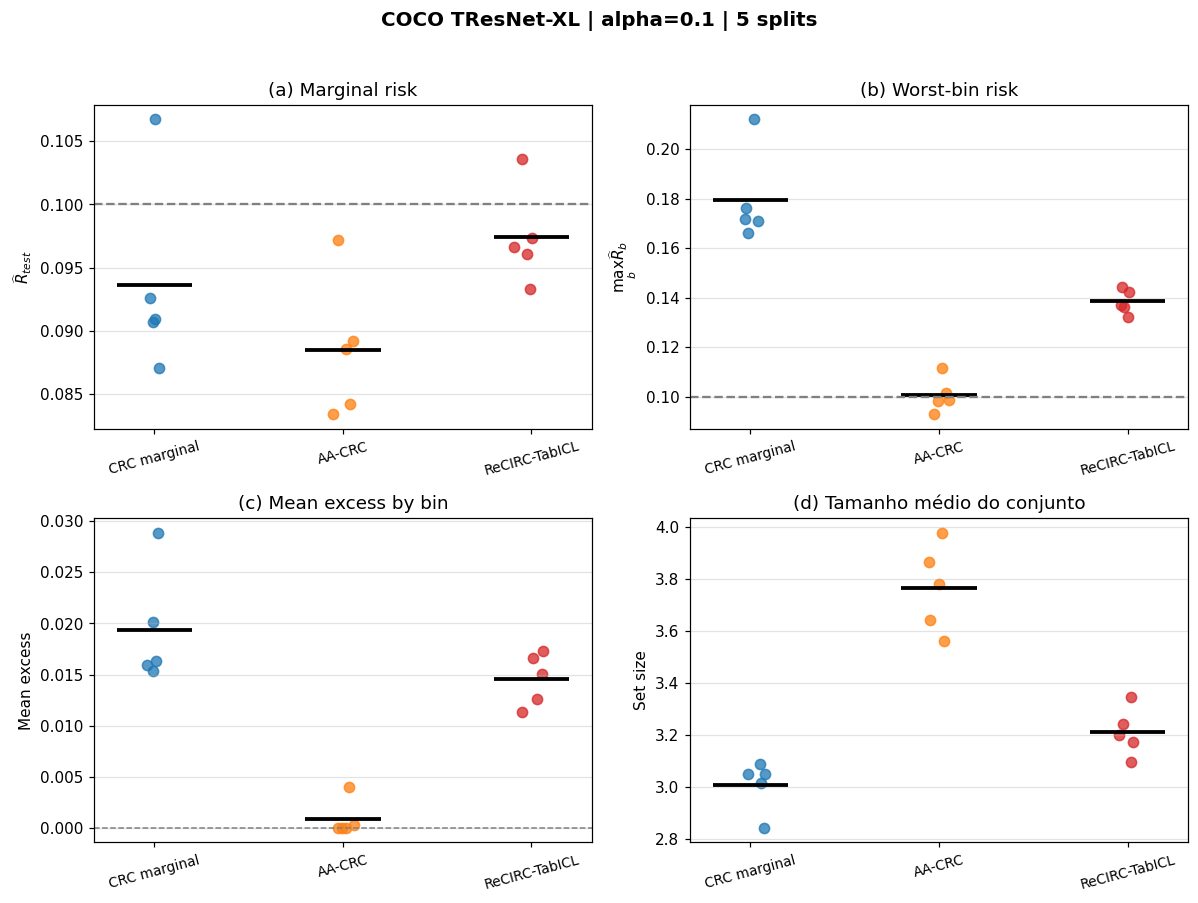

In [19]:
# ============================================================
# 4 paineis: risco marginal, worst-bin, mean excess, set size
# ============================================================
methods_order = [m for m in ["CRC marginal","AA-CRC","ReCIRC-TabICL"]
                 if m in df_marginal["method"].unique()]
palette = {"CRC marginal":"#1f77b4","AA-CRC":"#ff7f0e",
           "ReCIRC-TabICL":"#d62728"}

final_metrics = (df_marginal[["trial","method","test_fnr","avg_size"]]
    .merge(per_trial[["trial","method","worst_bin_risk","mean_excess_by_bin"]],
           on=["trial","method"], how="left"))

fig, axes = plt.subplots(2, 2, figsize=(11, 8)); axes = axes.ravel()
panels = [("test_fnr", r"$\widehat R_{test}$", "(a) Marginal risk", True),
          ("worst_bin_risk", r"$\max_b \widehat R_b$", "(b) Worst-bin risk", True),
          ("mean_excess_by_bin", "Mean excess", "(c) Mean excess by bin", False),
          ("avg_size", "Set size", "(d) Tamanho médio do conjunto", False)]
jit = np.random.default_rng(0)
for ax, (metric, ylab, title, show_a) in zip(axes, panels):
    for j, mth in enumerate(methods_order):
        tmp = final_metrics[final_metrics["method"] == mth]
        x = np.full(len(tmp), j, float) + jit.normal(0, .04, len(tmp))
        ax.scatter(x, tmp[metric], alpha=.75, s=45, color=palette.get(mth, "gray"))
        ax.hlines(tmp[metric].mean(), j-.2, j+.2, lw=2.5, color="black")
    if show_a: ax.axhline(ALPHA, ls="--", color="gray", lw=1.5)
    if metric == "mean_excess_by_bin": ax.axhline(0, ls="--", color="gray", lw=1.0)
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(methods_order, fontsize=9, rotation=15)
    ax.set_ylabel(ylab); ax.set_title(title); ax.grid(axis="y", alpha=.35)
fig.suptitle(f"COCO TResNet-XL | alpha={ALPHA} | {final_metrics['trial'].nunique()} splits",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


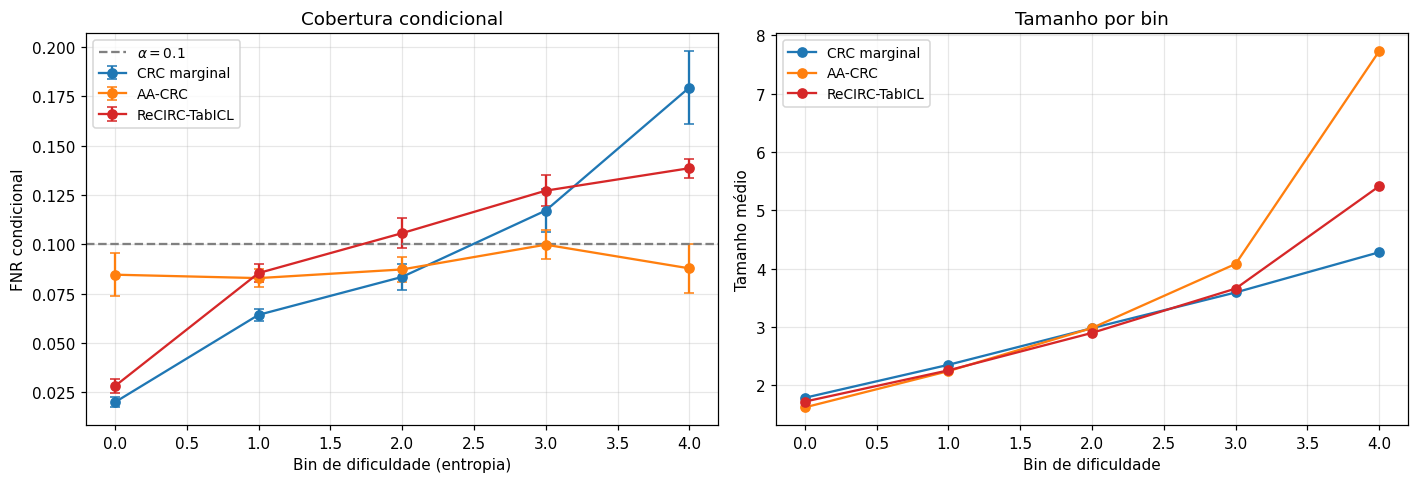

In [20]:
# ============================================================
# Cobertura condicional e tamanho por bin (media +- sd sobre splits)
# ============================================================
agg = (df_conditional.groupby(["method","bin"], as_index=False)
    .agg(mean_cond_risk=("conditional_risk","mean"), sd_cond_risk=("conditional_risk","std"),
         mean_size=("mean_set_size","mean")))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for mth in methods_order:
    tmp = agg[agg["method"] == mth].sort_values("bin")
    axes[0].errorbar(tmp["bin"], tmp["mean_cond_risk"], yerr=tmp["sd_cond_risk"],
                     marker="o", capsize=3, label=mth, color=palette.get(mth, "gray"))
    axes[1].plot(tmp["bin"], tmp["mean_size"], marker="o", label=mth, color=palette.get(mth, "gray"))
axes[0].axhline(ALPHA, ls="--", color="gray", label=fr"$\alpha={ALPHA}$")
axes[0].set_xlabel("Bin de dificuldade (entropia)"); axes[0].set_ylabel("FNR condicional")
axes[0].set_title("Cobertura condicional"); axes[0].legend(fontsize=9); axes[0].grid(alpha=.3)
axes[1].set_xlabel("Bin de dificuldade"); axes[1].set_ylabel("Tamanho médio")
axes[1].set_title("Tamanho por bin"); axes[1].legend(fontsize=9); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


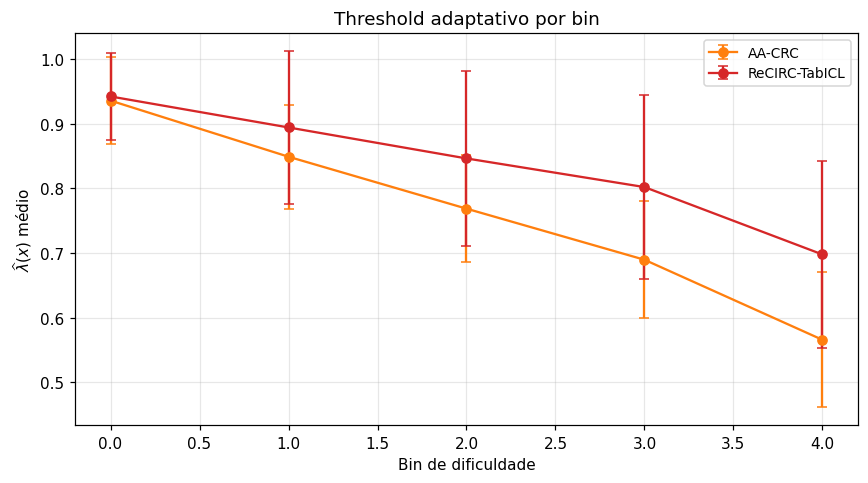

       method  bin  mean_lambda  sd_lambda
       AA-CRC    0       0.9358     0.0675
       AA-CRC    1       0.8490     0.0806
       AA-CRC    2       0.7688     0.0830
       AA-CRC    3       0.6898     0.0901
       AA-CRC    4       0.5660     0.1045
ReCIRC-TabICL    0       0.9422     0.0676
ReCIRC-TabICL    1       0.8943     0.1182
ReCIRC-TabICL    2       0.8464     0.1353
ReCIRC-TabICL    3       0.8021     0.1427
ReCIRC-TabICL    4       0.6980     0.1439


In [21]:
# ============================================================
# Adaptatividade: lambda(x) por bin (metodos adaptativos)
# ============================================================
if len(df_adapt):
    agg_a = (df_adapt.groupby(["method","bin"], as_index=False)
             .agg(mean_lambda=("mean_lambda","mean"), sd_lambda=("sd_lambda","mean")))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for mth in agg_a["method"].unique():
        tmp = agg_a[agg_a["method"] == mth].sort_values("bin")
        ax.errorbar(tmp["bin"], tmp["mean_lambda"], yerr=tmp["sd_lambda"],
                    marker="o", capsize=3, label=mth, color=palette.get(mth, "gray"))
    ax.set_xlabel("Bin de dificuldade"); ax.set_ylabel(r"$\widehat\lambda(x)$ médio")
    ax.set_title("Threshold adaptativo por bin"); ax.legend(fontsize=9); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    print(agg_a.round(4).to_string(index=False))


## 12. Apêndice — Per-class CRC (opcional)

Protege uma propriedade **diferente**: \(\mathbb E[1-\text{recall}_k]\le\alpha\) por classe \(k\), não FNR por imagem.
Não é concorrente direto do ReCIRC; serve de referência conceitual para o custo de garantias mais fortes.


In [22]:
def choose_lambda_per_class(scores, gt_labels, alpha, lambda_grid, B=1.0):
    K = scores.shape[1]; lambdas = np.zeros(K)
    for k in range(K):
        has_k = gt_labels[:, k] > 0; n_k = int(has_k.sum())
        if n_k == 0: continue
        sk = scores[has_k, k]
        risks = np.array([1.0 - (sk >= lam).mean() for lam in lambda_grid])
        bound = (n_k/(n_k+1))*risks + B/(n_k+1)
        valid = np.where(bound <= alpha)[0]
        lambdas[k] = float(lambda_grid[valid[-1]]) if len(valid) else 0.0
    return lambdas

lams_pc = choose_lambda_per_class(calM_scores, calM_labels, ALPHA, LAMBDA_GRID, B=B)
pred_pc = test_scores >= lams_pc[None, :]
ev_pc = evaluate_pred_set(pred_pc, test_labels)
print(f"Per-class CRC: FNR={ev_pc['fnr']:.4f} | tam={ev_pc['avg_size']:.2f} "
      f"| lambda_k médio={lams_pc.mean():.3f}±{lams_pc.std():.3f}")
print("Obs.: set size maior reflete o custo de controlar recall por classe.")


Per-class CRC: FNR=0.0652 | tam=6.69 | lambda_k médio=0.618±0.229
Obs.: set size maior reflete o custo de controlar recall por classe.


## 13. Notas finais

- **Argumento empírico central**: a planura da curva de risco condicional (Seção 11) + a dispersão de
  \(\widehat\lambda(x)\) por bin. A garantia formal é marginal; a condicionalidade é empírica.
- **AA-CRC vs ReCIRC com o mesmo \(\phi\)**: ambos partem de representações de probabilidade. Se ReCIRC achata
  mais a curva condicional, a evidência aponta para o valor da não-linearidade \(\phi\mapsto\lambda^\star\).
- **Confronto natural contra AA-CRC**: experimento polyp (Exp. 3 do PDF), com embeddings de imagem e
  implementação oficial. Aqui no COCO, AA-CRC é mais referência do que adversário ideal.
